In [2]:

import pandas as pd
import shutup
from utils.utils import process_txt_files, extract_json
shutup.please()
pd.options.display.max_columns = 10

In [5]:
folder_path = "../../data/outputs/hazard"
df = process_txt_files(folder_path, "hazard")
df.shape

(6644, 22)

# Merge with target

In [6]:
import requests
import pandas as pd
from io import StringIO

# URLs for the files
urls = [
    "https://raw.githubusercontent.com/food-hazard-detection-semeval-2025/food-hazard-detection-semeval-2025.github.io/refs/heads/main/data/incidents_train.csv",
    "https://raw.githubusercontent.com/food-hazard-detection-semeval-2025/food-hazard-detection-semeval-2025.github.io/refs/heads/main/data/incidents_valid.csv",
    "https://raw.githubusercontent.com/food-hazard-detection-semeval-2025/food-hazard-detection-semeval-2025.github.io/refs/heads/main/data/incidents_test.csv"
]

# Load each file into a DataFrame
dataframes = []
for url in urls:
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad status codes
    csv_data = StringIO(response.text)  # Convert text to a file-like object
    df_orig = pd.read_csv(csv_data)
    dataframes.append(df_orig)


# Access the DataFrames
train_df, valid_df, test_df = dataframes

# Example: Display the first few rows of the training DataFrame
print(train_df.head())

   Unnamed: 0  year  month  day country  ...  \
0           0  1994      1    7      us  ...   
1           1  1994      3   10      us  ...   
2           2  1994      3   28      us  ...   
3           3  1994      4    3      us  ...   
4           4  1994      7    1      us  ...   

                                                text hazard-category  \
0  Case Number: 024-94   \n            Date Opene...      biological   
1  Case Number: 033-94   \n            Date Opene...      biological   
2  Case Number: 014-94   \n            Date Opene...      biological   
3  Case Number: 009-94   \n            Date Opene...  foreign bodies   
4  Case Number: 001-94   \n            Date Opene...  foreign bodies   

               product-category                  hazard  \
0  meat, egg and dairy products  listeria monocytogenes   
1  meat, egg and dairy products            listeria spp   
2  meat, egg and dairy products  listeria monocytogenes   
3  meat, egg and dairy products        pla

In [7]:
valid_df.shape[0] + train_df.shape[0] + test_df.shape[0]

6644

In [8]:
df

,id,custom_id,product_type,hazard_type,recall_reason,...,product_batch_code,recall_notification_method,product_size,recall_frequency,recall_duration
0,batch_req_67f8e745917481909a25a7c49dfcb645,0,Chicken,biological,Contamination,...,024-94,Press Release,"2,894",Low,Medium
1,batch_req_67f8e745a2648190a8924db8613ebee3,1,Other,biological,Contamination,...,N/A,Press Release,"5,500",Low,Long
2,batch_req_67f8e745b3ec81908877fd1900fdad4b,2,Other,biological,Contamination,...,014-94,Press Release,"3,950",Low,Medium
3,batch_req_67f8e745c7e08190ab5eab8a33796e44,3,Other,foreign bodies,Contamination,...,009-94,Press Release,"16,164 pounds",Low,Medium
4,batch_req_67f8e745da708190b36448f0d537e549,4,Chicken,foreign bodies,Contamination,...,001-94,Press Release,"46,168 pounds",Low,Medium
...,...,...,...,...,...,...,...,...,...,...,...
6639,batch_req_67fa7ba957208190ab33c663f71244e0,6639,Chicken,allergens,Undeclared Allergen,...,"LOT 016522, LOT 016422, LOT 013622, LOT 012922...",Email,"450 g, 1 kg",Medium,Short
6640,batch_req_67fa7ba969988190a57ab337c8dcfe85,6640,Other,biological,Contamination,...,"22-102, 22-103, 22-130, 22-194",Press Release,1-pound,Low,Short
6641,batch_req_67fa7ba97d40819083880aa9f4629d1b,6641,Seafood,biological,Contamination,...,"1- 14:181 | 2- 14:174 | 3- 14:180 | 4- 14:171,...",Press Release,"150g, 100g, 250g, 500g, 1kg",Medium,Short
6642,batch_req_67fa7ba98d488190989c7d46d1595de9,6642,Snack,chemical,Contamination,...,Other,In-Store Notice,Other,Low,Short


In [9]:
df = df.drop(columns=["id", "custom_id"])
# Convert any list values in the DataFrame to strings
for col in df.columns:
    df[col] = df[col].apply(lambda x: str(x) if isinstance(x, list) else x)

# Now apply get_dummies
df = pd.get_dummies(df, sparse=False, prefix_sep='_')

In [10]:
df.shape

(6644, 7931)

### Sub Task 1 - ST1
- hazard-category, product-category

In [11]:

X_train = df.iloc[:train_df.shape[0]+valid_df.shape[0]]
X_test = df.tail(len(test_df))
y_train = pd.concat([train_df['hazard-category'], valid_df['hazard-category']])
hazard_true = test_df['hazard-category']
# y_valid = valid_df['hazard-category']

In [12]:
# 1) Libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score


# ----------------------------------------------------------------
# 4) Definice modelu RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# 5) Nastavení rozsahu parametrů pro RandomizedSearchCV
param_dist = {
    "n_estimators": [50, 100, 200],       # Počet stromů v lese
    "max_depth": [3, 5, 10, None],        # Maximální hloubka stromu
    "min_samples_split": [2, 5, 10],      # Minimální počet vzorků pro split
    "min_samples_leaf": [1, 2, 5],        # Minimální počet vzorků v listu
}

# 6) Konfigurace RandomizedSearchCV (n_iter a cv lze upravit dle potřeby)
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,             # kolik náhodných kombinací parametrů prozkoumat
    cv=5,                  # 5-fold cross-validace
    scoring="f1_macro",    # metrika, dle které se bude model porovnávat
    random_state=42,
    n_jobs=-1,             # využití všech CPU jader pro rychlejší výpočet
    verbose=1
)

# 7) Trénink modelu s vyhledáváním nejlepších hyperparametrů
random_search.fit(X_train, y_train)

# 8) Vypsání nejlepších parametrů a skóre
print("Nejlepší parametry:", random_search.best_params_)
print("Nejlepší skóre na trénovací cross-validaci:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Nejlepší parametry: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Nejlepší skóre na trénovací cross-validaci: 0.6122779514195333


In [13]:

# 9) Ověření na testovací sadě
best_model = random_search.best_estimator_  # získáme nejlepší nalezený model
hazard_pred = best_model.predict(X_test)

# 10) Vyhodnocení
print("Přesnost na testu:", accuracy_score(hazard_true, hazard_pred))
print("Classification report na testu:")
print(classification_report(hazard_true ,hazard_pred, zero_division=0))

Přesnost na testu: 0.9348044132397192
Classification report na testu:
                                precision    recall  f1-score   support

                     allergens       0.95      0.99      0.97       365
                    biological       0.95      0.99      0.97       343
                      chemical       0.91      0.92      0.91        52
food additives and flavourings       1.00      0.50      0.67         4
                foreign bodies       0.96      0.98      0.97       111
                         fraud       0.86      0.72      0.78        75
                     migration       0.00      0.00      0.00         1
          organoleptic aspects       0.60      0.30      0.40        10
                  other hazard       0.75      0.23      0.35        26
              packaging defect       0.73      0.80      0.76        10

                      accuracy                           0.93       997
                     macro avg       0.77      0.64      0.68   

In [14]:
import shap

# Create the SHAP explainer for the tree-based model
explainer = shap.Explainer(best_model, X_train)

# Get SHAP values for the test set
shap_values = explainer(X_test)

100%|===================| 9963/9970 [21:02<00:00]        

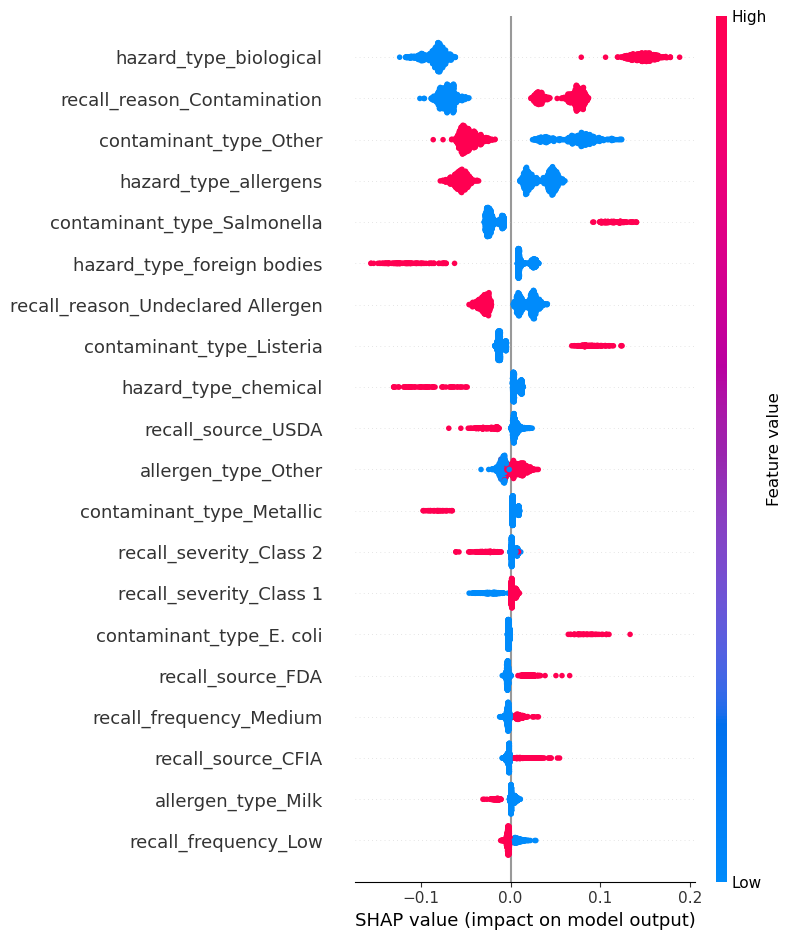

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[:, :, 1],  # Use the SHAP values for class 0 - allergens
    X_test,
    class_names=best_model.classes_,
    max_display=20,
    show=False
)
plt.savefig(f"hazard_class_1_shap.pdf", format="pdf", bbox_inches="tight")


In [16]:
y_train = pd.concat([train_df['product-category'], valid_df['product-category']])
product_true = test_df['product-category']

In [17]:
# 1) Libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score


# ----------------------------------------------------------------
# 4) Definice modelu RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# 5) Nastavení rozsahu parametrů pro RandomizedSearchCV
param_dist = {
    "n_estimators": [100, 200, 300, 500],       # Počet stromů v lese
    "max_depth": [3, 5, 10, None],        # Maximální hloubka stromu
    "min_samples_split": [2, 5, 10],      # Minimální počet vzorků pro split
    "min_samples_leaf": [1, 2, 5],        # Minimální počet vzorků v listu
}

# 6) Konfigurace RandomizedSearchCV (n_iter a cv lze upravit dle potřeby)
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,             # kolik náhodných kombinací parametrů prozkoumat
    cv=5,                  # 5-fold cross-validace
    scoring="f1_macro",    # metrika, dle které se bude model porovnávat
    random_state=42,
    n_jobs=-1,             # využití všech CPU jader pro rychlejší výpočet
    verbose=1
)

# 7) Trénink modelu s vyhledáváním nejlepších hyperparametrů
random_search.fit(X_train, y_train)

# 8) Vypsání nejlepších parametrů a skóre
print("Nejlepší parametry:", random_search.best_params_)
print("Nejlepší skóre na trénovací cross-validaci:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Nejlepší parametry: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Nejlepší skóre na trénovací cross-validaci: 0.2862217504063953


In [18]:

# 9) Ověření na testovací sadě
best_model = random_search.best_estimator_  # získáme nejlepší nalezený model
product_pred = best_model.predict(X_test)

# 10) Vyhodnocení
print("Přesnost na testu:", accuracy_score(product_true, product_pred))
print("Classification report na testu:")
print(classification_report(product_true, product_pred, zero_division=0))

Přesnost na testu: 0.6058174523570712
Classification report na testu:
                                                   precision    recall  f1-score   support

                              alcoholic beverages       1.00      0.75      0.86        16
                      cereals and bakery products       0.36      0.64      0.46       121
     cocoa and cocoa preparations, coffee and tea       0.67      0.71      0.69        42
                                    confectionery       1.00      0.18      0.31        33
dietetic foods, food supplements, fortified foods       1.00      0.12      0.21        26
                                    fats and oils       1.00      0.33      0.50         6
                   food additives and flavourings       1.00      0.25      0.40         4
                            fruits and vegetables       0.54      0.45      0.49       103
                                 herbs and spices       0.67      0.20      0.31        20
                   

In [19]:
def compute_score(hazards_true, products_true, hazards_pred, products_pred):
    f1_hazards = f1_score(
        hazards_true,
        hazards_pred,
        average='macro'
    )
    print(f"F1 for hazard-category: {round(f1_hazards, 2)}")
    f1_products = f1_score(
        products_true[hazards_pred == hazards_true],
        products_pred[hazards_pred == hazards_true],
        average='macro'
    )
    print(f"F1 for product-category: {round(f1_products, 2)}")
    return (f1_hazards + f1_products) / 2.

print(f"Final ST1 F1 score: {round(compute_score(hazard_true, product_true, hazard_pred, product_pred), 2)}")

F1 for hazard-category: 0.68
F1 for product-category: 0.46
Final ST1 F1 score: 0.57


### Subtask 2 - ST2

- products, hazards

In [20]:
X_train = df.iloc[:train_df.shape[0]+valid_df.shape[0]]
X_test = df.tail(len(test_df))
y_train = pd.concat([train_df['hazard'], valid_df['hazard']])
hazard_true = test_df['hazard']

In [21]:
# 4) Definice modelu RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# 5) Nastavení rozsahu parametrů pro RandomizedSearchCV
param_dist = {
    "n_estimators": [50, 100, 200],       # Počet stromů v lese
    "max_depth": [3, 5, 10, None],        # Maximální hloubka stromu
    "min_samples_split": [2, 5, 10],      # Minimální počet vzorků pro split
    "min_samples_leaf": [1, 2, 5],        # Minimální počet vzorků v listu
}

# 6) Konfigurace RandomizedSearchCV (n_iter a cv lze upravit dle potřeby)
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,             # kolik náhodných kombinací parametrů prozkoumat
    cv=5,                  # 5-fold cross-validace
    scoring="f1_macro",    # metrika, dle které se bude model porovnávat
    random_state=42,
    n_jobs=-1,             # využití všech CPU jader pro rychlejší výpočet
    verbose=1
)

# 7) Trénink modelu s vyhledáváním nejlepších hyperparametrů
random_search.fit(X_train, y_train)

# 8) Vypsání nejlepších parametrů a skóre
print("Nejlepší parametry:", random_search.best_params_)
print("Nejlepší skóre na trénovací cross-validaci:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Nejlepší parametry: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Nejlepší skóre na trénovací cross-validaci: 0.29256031201742944


In [22]:
best_model = random_search.best_estimator_
hazard_pred = best_model.predict(X_test)

print("Přesnost na testu:", accuracy_score(hazard_true, hazard_pred))
print("Classification report na testu:")
print(classification_report(hazard_true ,hazard_pred, zero_division=0))

Přesnost na testu: 0.7763289869608826
Classification report na testu:
                                                 precision    recall  f1-score   support

                                      Aflatoxin       1.00      0.50      0.67         2
                                 abnormal smell       0.00      0.00      0.00         1
                                alcohol content       0.00      0.00      0.00         1
                                      alkaloids       0.00      0.00      0.00         1
                                      allergens       0.00      0.00      0.00         3
                                         almond       0.53      0.69      0.60        13
                                      amygdalin       0.00      0.00      0.00         1
                         antibiotics, vet drugs       0.00      0.00      0.00         1
                                  bacillus spp.       0.50      0.33      0.40         3
                           bad smell / 

In [23]:
y_train = pd.concat([train_df['product'], valid_df['product']])
product_true = test_df['product']

In [24]:
# 1) Libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score


# ----------------------------------------------------------------
# 4) Definice modelu RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# 5) Nastavení rozsahu parametrů pro RandomizedSearchCV
param_dist = {
    "n_estimators": [100, 200, 300, 500],       # Počet stromů v lese
    "max_depth": [3, 5, 10, None],        # Maximální hloubka stromu
    "min_samples_split": [2, 5, 10],      # Minimální počet vzorků pro split
    "min_samples_leaf": [1, 2, 5],        # Minimální počet vzorků v listu
}

# 6) Konfigurace RandomizedSearchCV (n_iter a cv lze upravit dle potřeby)
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,             # kolik náhodných kombinací parametrů prozkoumat
    cv=5,                  # 5-fold cross-validace
    scoring="f1_macro",    # metrika, dle které se bude model porovnávat
    random_state=42,
    n_jobs=-1,             # využití všech CPU jader pro rychlejší výpočet
    verbose=1
)

# 7) Trénink modelu s vyhledáváním nejlepších hyperparametrů
random_search.fit(X_train, y_train)

# 8) Vypsání nejlepších parametrů a skóre
print("Nejlepší parametry:", random_search.best_params_)
print("Nejlepší skóre na trénovací cross-validaci:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Nejlepší parametry: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Nejlepší skóre na trénovací cross-validaci: 0.10294299367415646


In [25]:

# 9) Ověření na testovací sadě
best_model = random_search.best_estimator_  # získáme nejlepší nalezený model
product_pred = best_model.predict(X_test)

# 10) Vyhodnocení
print("Přesnost na testu:", accuracy_score(product_true, product_pred))
print("Classification report na testu:")
print(classification_report(product_true, product_pred, zero_division=0))

Přesnost na testu: 0.24573721163490472
Classification report na testu:
                                                               precision    recall  f1-score   support

                                       Catfishes (freshwater)       0.50      1.00      0.67         3
                                              Dried pork meat       0.00      0.00      0.00         1
                                        Fishes not identified       0.36      0.62      0.45         8
                                     Not classified pork meat       0.00      0.00      0.00         3
                          Precooked cooked pork meat products       0.00      0.00      0.00         1
                                            Saurida (generic)       0.00      0.00      0.00         1
                                                Veggie Burger       1.00      1.00      1.00         1
                                              alfalfa sprouts       0.00      0.00      0.00         0
 

In [26]:
from sklearn.metrics import f1_score


def compute_score(hazards_true, products_true, hazards_pred, products_pred):
    # compute f1 for hazards:
    f1_hazards = f1_score(
        hazards_true,
        hazards_pred,
        average='macro'
    )
    print(f"F1 for hazard-category: {round(f1_hazards, 2)}")
    # compute f1 for products:
    f1_products = f1_score(
        products_true[hazards_pred == hazards_true],
        products_pred[hazards_pred == hazards_true],
        average='macro'
    )
    print(f"F1 for product-category: {round(f1_products, 2)}")
    return (f1_hazards + f1_products) / 2.

print(f"Final ST2 F1 score: {round(compute_score(hazard_true, product_true, hazard_pred, product_pred), 2)}")

F1 for hazard-category: 0.34
F1 for product-category: 0.12
Final ST2 F1 score: 0.23
